# RavenStack Customer & Revenue Analysis
### What Drives Customer Retention and Revenue Expansion at RavenStack?

**Author:** Elene Kikalishvili  
**Dataset:** SaaS Subscription & Churn Analytics Dataset by River @ Rivalytics  
**Tools:** Python · pandas · matplotlib · seaborn

---
## Project Overview

RavenStack is a stealth-mode B2B SaaS startup delivering AI-powered team collaboration and developer tools. After a closed pilot with coding bootcamp graduates, the company is preparing for public launch across three subscription tiers - Basic, Pro, and Enterprise.

Despite steady account growth, the business faces elevated churn and uneven revenue expansion. This analysis investigates what drives long-term customer retention and revenue growth using five interconnected data tables spanning subscriptions, product usage, support activity, and churn events.

**Key Questions:**
- Q1: Which customer segments generate the highest revenue and long-term value?
- Q2: Which referral sources and industries produce the highest-value customers, measured by LTV, MRR, and churn rate?
- Q3: What does the journey from trial → upgrade → churn look like, and where does revenue expand or collapse?
- Q4: Which features drive product value, and do engaged users retain better?
- Q5: Which support experience patterns are associated with increased churn risk?
- Q6: How do different signup cohorts retain and expand over time?

---

## Data Understanding & Preparation
### Imports & Loading

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all five tables

accounts = pd.read_csv('data/ravenstack_accounts.csv')
subscriptions = pd.read_csv('data/ravenstack_subscriptions.csv')
feature_usage = pd.read_csv('data/ravenstack_feature_usage.csv')
support_tickets = pd.read_csv('data/ravenstack_support_tickets.csv')
churn_events = pd.read_csv('data/ravenstack_churn_events.csv')

print("All tables loaded successfully")
print(f"accounts: {accounts.shape}")
print(f"subscriptions: {subscriptions.shape}")
print(f"feature_usage: {feature_usage.shape}")
print(f"support_tickets: {support_tickets.shape}")
print(f"churn_events: {churn_events.shape}")


All tables loaded successfully
accounts: (500, 10)
subscriptions: (5000, 14)
feature_usage: (25000, 8)
support_tickets: (2000, 9)
churn_events: (600, 9)


### Exploration

#### Quick profile of all five tables
##### Detailed per-table exploration and findings follow below.

In [81]:
# create tables dictionary

dfs = {
    'accounts': accounts,
    'subscriptions': subscriptions,
    'feature_usage': feature_usage,
    'support_tickets': support_tickets,
    'curn_events': churn_events
}

for name, df in dfs.items() :
    print(f"\n{'-'*50}")
    print(f"TABLE: {name.upper()}")
    print(f"Shape: {df.shape}")
    print(f"{'-'*50}")

    print("\n--- Nulls per column ---")
    print(df.isnull().sum())

    # select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns

    # filter out id columns
    clean_metrics = [c for c in numeric_cols if 'id' not in c.lower()]

    display(df[clean_metrics].describe())
    



--------------------------------------------------
TABLE: ACCOUNTS
Shape: (500, 10)
--------------------------------------------------

--- Nulls per column ---
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64


,seats
count,500.000000
mean,20.560000
std,21.044718
min,1.000000
25%,5.000000
50%,15.000000
75%,28.000000
max,163.000000



--------------------------------------------------
TABLE: SUBSCRIPTIONS
Shape: (5000, 14)
--------------------------------------------------

--- Nulls per column ---
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64


,seats,mrr_amount,arr_amount
count,5000.000000,5000.000000,5000.000000
mean,29.852000,2267.749400,27212.992800
std,23.089771,3421.375348,41056.504178
min,1.000000,0.000000,0.000000
25%,14.000000,285.000000,3420.000000
50%,24.000000,931.000000,11172.000000
75%,40.000000,2786.000000,33432.000000
max,189.000000,33830.000000,405960.000000



--------------------------------------------------
TABLE: FEATURE_USAGE
Shape: (25000, 8)
--------------------------------------------------

--- Nulls per column ---
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64


,usage_count,usage_duration_secs,error_count
count,25000.000000,25000.000000,25000.000000
mean,10.021000,3042.202880,0.564280
std,3.143729,2056.544615,1.012595
min,0.000000,0.000000,0.000000
25%,8.000000,1350.000000,0.000000
50%,10.000000,2760.000000,0.000000
75%,12.000000,4400.000000,1.000000
max,26.000000,12696.000000,8.000000



--------------------------------------------------
TABLE: SUPPORT_TICKETS
Shape: (2000, 9)
--------------------------------------------------

--- Nulls per column ---
ticket_id                        0
account_id                       0
submitted_at                     0
closed_at                        0
resolution_time_hours            0
priority                         0
first_response_time_minutes      0
satisfaction_score             825
escalation_flag                  0
dtype: int64


,resolution_time_hours,first_response_time_minutes,satisfaction_score
count,2000.000000,2000.000000,1175.000000
mean,35.861000,88.480000,3.981277
std,21.138427,51.531877,0.809646
min,1.000000,1.000000,3.000000
25%,17.000000,43.000000,3.000000
50%,35.000000,88.000000,4.000000
75%,54.000000,131.000000,5.000000
max,72.000000,180.000000,5.000000



--------------------------------------------------
TABLE: CURN_EVENTS
Shape: (600, 9)
--------------------------------------------------

--- Nulls per column ---
churn_event_id                0
account_id                    0
churn_date                    0
reason_code                   0
refund_amount_usd             0
preceding_upgrade_flag        0
preceding_downgrade_flag      0
is_reactivation               0
feedback_text               148
dtype: int64


,refund_amount_usd
count,600.000000
mean,14.420417
std,39.224591
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,392.920000


#### accounts

In [67]:
# accounts table - structure and first rows

print("ACCOUNTS TABLE")
print(f"shape: {accounts.shape}")
print("\n--- First 5 rows ---")
display(accounts.head())
print("\n--- Column Types & Nulls ---")
print(accounts.info())


ACCOUNTS TABLE
shape: (500, 10)

--- First 5 rows ---


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True



--- Column Types & Nulls ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB
None


**Structure:**  
The accounts table has 500 rows and 10 columns with no nulls across any column - the table is complete.  
Column types are mostly strings, with `seats` as integer and `is_trial` and `churn_flag` as booleans.  
One issue to fix in cleaning: `signup_date` is currently a string and needs to be converted to a proper datetime type for cohort analysis in Q6.

In [68]:
# numeric stats

print("--- Numeric Column Stats ---")
display(accounts.describe())


--- Numeric Column Stats ---


,seats
count,500.000000
mean,20.560000
std,21.044718
min,1.000000
25%,5.000000
50%,15.000000
75%,28.000000
max,163.000000


**Seats distribution:**  
The median account has 15 licensed seats, suggesting most RavenStack customers are small to mid-sized teams.  
The mean (20.5) is higher than the median, suggesting the distribution is right-skewed - some accounts have significantly more seats than the typical customer, with the largest account holding 163 seats.

In [18]:
# categorical distributions and checks

print("--- Plan Tier Distribution ---")
print(accounts['plan_tier'].value_counts())

print("\n--- Referral Source Distribution ---")
print(accounts['referral_source'].value_counts())

print("\n--- Industry Distribution ---")
print(accounts['industry'].value_counts())

print("\n--- Trial vs Non-Trial ---")
print(accounts['is_trial'].value_counts())

print("\n--- Churn Flag Distribution ---")
print(accounts['churn_flag'].value_counts())

print("\n--- Duplicate account_id check ---")
print(f"{accounts['account_id'].duplicated().sum()} duplicate account_ids")


--- Plan Tier Distribution ---
plan_tier
Pro           178
Basic         168
Enterprise    154
Name: count, dtype: int64

--- Referral Source Distribution ---
referral_source
organic    114
other      103
ads         98
event       96
partner     89
Name: count, dtype: int64

--- Industry Distribution ---
industry
DevTools         113
FinTech          112
Cybersecurity    100
HealthTech        96
EdTech            79
Name: count, dtype: int64

--- Trial vs Non-Trial ---
is_trial
False    403
True      97
Name: count, dtype: int64

--- Churn Flag Distribution ---
churn_flag
False    390
True     110
Name: count, dtype: int64

--- Duplicate account_id check ---
0 duplicate account_ids


**Distributions & checks:**  

**Plan tier** - fairly evenly distributed: Pro (178), Basic (168), Enterprise (154). No single tier dominates.

**Referral source** - organic leads (114), followed closely by other, ads, event, and partner. Fairly balanced, no single channel overwhelmingly dominates.

**Industry** - DevTools (113) and FinTech (112) are the largest segments, EdTech (79) the smallest. Five industries total, clean categories, no typos.

**Trial vs non-trial** - 97 accounts are currently on trial, 403 are not. That's about 19% of accounts in trial status.

**Churn flag** - 110 accounts have churned (True), 390 are active (False).

**Duplicates** - 0 duplicate account_ids. The table is clean.

---
#### subscriptions

In [69]:
# subscriptions - structure and first rows 

print("SUBSCRIPTIONS TABLE")
print(f"Shape: {subscriptions.shape}")
print("\n--- First 5 rows ---")
display(subscriptions.head())
print("\n--- Column Types & Nulls ---")
print(subscriptions.info())


SUBSCRIPTIONS TABLE
Shape: (5000, 14)

--- First 5 rows ---


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True



--- Column Types & Nulls ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   start_date         5000 non-null   str  
 3   end_date           486 non-null    str  
 4   plan_tier          5000 non-null   str  
 5   seats              5000 non-null   int64
 6   mrr_amount         5000 non-null   int64
 7   arr_amount         5000 non-null   int64
 8   is_trial           5000 non-null   bool 
 9   upgrade_flag       5000 non-null   bool 
 10  downgrade_flag     5000 non-null   bool 
 11  churn_flag         5000 non-null   bool 
 12  billing_frequency  5000 non-null   str  
 13  auto_renew_flag    5000 non-null   bool 
dtypes: bool(5), int64(3), str(6)
memory usage: 376.1 KB
None


**Structure:**  
The subscriptions table has 5,000 rows and 14 columns across 500 accounts - an average of 10 subscription records per account, reflecting trials, upgrades, downgrades, and renewals over time.  
No nulls except `end_date`, which has only 486 non-null values - this is expected, as null `end_date` indicates an active subscription.  
Both `start_date` and `end_date` are currently strings and need to be converted to datetime in cleaning.  
One observation: trial subscriptions (row 2 in head) show `mrr_amount = 0` - trials will need to be excluded when calculating active MRR.  

In [70]:
# numeric stats

print("--- Numeric Column Stats ---")
display(subscriptions.describe())


--- Numeric Column Stats ---


,seats,mrr_amount,arr_amount
count,5000.000000,5000.000000,5000.000000
mean,29.852000,2267.749400,27212.992800
std,23.089771,3421.375348,41056.504178
min,1.000000,0.000000,0.000000
25%,14.000000,285.000000,3420.000000
50%,24.000000,931.000000,11172.000000
75%,40.000000,2786.000000,33432.000000
max,189.000000,33830.000000,405960.000000


**Numeric stats:**  
Median MRR per subscription is \\$931, but the mean is \\$2,268 - a significant gap indicating a right-skewed distribution where a small number of high-value subscriptions pull the average up considerably.  
The minimum MRR of \\$0 confirms trial subscriptions are included in this table and must be excluded from active MRR calculations.  
The largest subscription generates \\$33,830 MRR (\\$405,960 ARR), suggesting at least one significant enterprise contract in the dataset.


In [27]:
# categorical distributions and checks

print("--- Plan Tier Distribution ---")
print(subscriptions['plan_tier'].value_counts())

print("\n--- Billing Frequency ---")
print(subscriptions['billing_frequency'].value_counts())

print("\n--- Trial Subscriptions ---")
print(subscriptions['is_trial'].value_counts())

print("\n--- Upgrade / Downgrade Flags ---")
print(f"Upgrades:   {subscriptions['upgrade_flag'].sum()}")
print(f"Downgrades: {subscriptions['downgrade_flag'].sum()}")

print("\n--- Duplicate subscription_id check ---")
print(f"Duplicate subscription_ids: {subscriptions['subscription_id'].duplicated().sum()}")


--- Plan Tier Distribution ---
plan_tier
Enterprise    1723
Pro           1675
Basic         1602
Name: count, dtype: int64

--- Billing Frequency ---
billing_frequency
monthly    2539
annual     2461
Name: count, dtype: int64

--- Trial Subscriptions ---
is_trial
False    4222
True      778
Name: count, dtype: int64

--- Upgrade / Downgrade Flags ---
Upgrades:   529
Downgrades: 218

--- Duplicate subscription_id check ---
Duplicate subscription_ids: 0


**Distributions & checks:**  

**Plan tier** - Enterprise has the most subscription records (1,723), followed by Pro (1,675) and Basic (1,602). Fairly balanced but Enterprise slightly leads - important because Enterprise subscriptions carry the highest MRR.  

**Billing frequency** - almost a 50/50 split between monthly (2,539) and annual (2,461). Annual subscribers typically have higher LTV and lower churn risk.  

**Trial subscriptions** - 778 trial records out of 5,000 total. These will be excluded from active MRR calculations.  

**Upgrades vs downgrades** - 529 upgrades and 218 downgrades. Upgrades outnumber downgrades by more than 2:1, which is a positive signal for revenue expansion.   

**Duplicates** - 0 duplicate subscription_ids. Clean.

---
#### feature_usage

In [71]:
# feature_usage - structure and first rows

print("FEATURE USAGE TABLE")
print(f"Shape: {feature_usage.shape}")
print("\n--- First 5 rows ---")
display(feature_usage.head())
print("\n--- Column Types & Nulls ---")
print(feature_usage.info())


FEATURE USAGE TABLE
Shape: (25000, 8)

--- First 5 rows ---


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



--- Column Types & Nulls ---
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   usage_id             25000 non-null  str  
 1   subscription_id      25000 non-null  str  
 2   usage_date           25000 non-null  str  
 3   feature_name         25000 non-null  str  
 4   usage_count          25000 non-null  int64
 5   usage_duration_secs  25000 non-null  int64
 6   error_count          25000 non-null  int64
 7   is_beta_feature      25000 non-null  bool 
dtypes: bool(1), int64(3), str(4)
memory usage: 1.4 MB
None


**Structure:**  
The feature_usage table has 25,000 rows and 8 columns with no nulls across any column - the table is complete.  
This is the largest table in the dataset and links to subscriptions via `subscription_id`.   
`usage_date` is currently a string and needs to be converted to datetime in cleaning.  
The three numeric columns - `usage_count`,`usage_duration_secs`, and `error_count` - are the inputs for the engagement score calculated in Q4.

In [72]:
# numeric stats

print("--- Numeric Column Stats ---")
display(feature_usage.describe())


--- Numeric Column Stats ---


,usage_count,usage_duration_secs,error_count
count,25000.000000,25000.000000,25000.000000
mean,10.021000,3042.202880,0.564280
std,3.143729,2056.544615,1.012595
min,0.000000,0.000000,0.000000
25%,8.000000,1350.000000,0.000000
50%,10.000000,2760.000000,0.000000
75%,12.000000,4400.000000,1.000000
max,26.000000,12696.000000,8.000000


**Numeric stats:**  
Average usage count per event is 10, with a tight distribution (min 0, max 26) - usage frequency is fairly consistent across records.  
Usage duration varies more widely - median is 2,760 seconds (~46 minutes) but the mean is 3,042 seconds (~51 minutes), with a max of 12,696 seconds (~3.5 hours), suggesting some features drive significantly longer sessions.  
Error count is low overall - median is 0 and mean is 0.56, meaning most usage events produce no errors, though the max of 8 errors in a single event is worth monitoring in Q4 feature analysis.

In [39]:
# categorical distributions and checks

print("--- Number of Features ---")
print(f"Unique features: {feature_usage['feature_name'].nunique()}")

print("--- Top 10 Features by Usage Records ---")
print(feature_usage['feature_name'].value_counts().head(10))

print("\n--- Beta vs Standard Features ---")
print(feature_usage['is_beta_feature'].value_counts())

print("\n--- Usage Date Range ---")
print(f"Earliest date: {feature_usage['usage_date'].min()}")
print(f"Latest date:   {feature_usage['usage_date'].max()}")

print("\n--- Subscriptions represented in feature_usage ---")
print(f"Unique subscription_ids: {feature_usage['subscription_id'].nunique()}")
print(f"Total subscriptions in subscriptions table: {subscriptions.shape[0]}")

print("\n--- Duplicate usage_id check ---")
print(f"Duplicate usage_ids: {feature_usage['usage_id'].duplicated().sum()}")


--- Number of Features ---
Unique features: 40
--- Top 10 Features by Usage Records ---
feature_name
feature_12    659
feature_32    659
feature_6     655
feature_17    651
feature_34    650
feature_26    649
feature_36    648
feature_31    644
feature_20    643
feature_24    643
Name: count, dtype: int64

--- Beta vs Standard Features ---
is_beta_feature
False    22456
True      2544
Name: count, dtype: int64

--- Usage Date Range ---
Earliest date: 2023-01-01
Latest date:   2024-12-31

--- Subscriptions represented in feature_usage ---
Unique subscription_ids: 4967
Total subscriptions in subscriptions table: 5000

--- Duplicate usage_id check ---
Duplicate usage_ids: 21


In [37]:
# investigate duplicate usage_ids 

duplicates = feature_usage[feature_usage['usage_id'].duplicated(keep=False)]
print(f"Total rows involved in duplicates: {len(duplicates)}")
print(duplicates.sort_values('usage_id').head(10))


Total rows involved in duplicates: 42
       usage_id subscription_id  usage_date feature_name  usage_count  \
19294  U-0c9318        S-01b2dc  2023-12-11    feature_9            5   
17533  U-0c9318        S-0ffab0  2024-01-30   feature_11            3   
20588  U-13ce5b        S-9b623b  2023-03-26   feature_28           10   
9626   U-13ce5b        S-8b0950  2024-09-10    feature_9            8   
18480  U-2103bb        S-7fc49b  2023-04-18   feature_12            9   
10379  U-2103bb        S-ae3270  2024-01-06    feature_3           10   
22     U-25b56c        S-810c27  2024-10-06   feature_20            7   
7574   U-25b56c        S-34253c  2023-10-28   feature_20            6   
21376  U-48a4aa        S-93f835  2024-08-24   feature_39           10   
1085   U-48a4aa        S-383ac2  2023-02-12   feature_28           14   

       usage_duration_secs  error_count  is_beta_feature  
19294                 1060            3            False  
17533                 1614            0 

**Distributions & checks:**  
The top 10 features out of 40 by record count show very even distribution, ranging from 643 to 659 records each - no single feature dominates, suggesting analysis of total usage volume and duration will be more meaningful than record count alone.  
Beta features account for approximately 10% of all usage records, matching expected distribution.  
Data spans exactly two years (2023-2024).  
33 subscriptions have no feature usage records - likely new or immediately churned accounts.  
21 duplicate usage_ids were found and investigated - these are ID generation collisions, not true duplicate events, as all other fields differ between pairs.  
All rows will be retained in cleaning.

---
#### support_tickets

In [73]:
# support_tickets - structure and first rows

print("SUPPORT TICKETS TABLE")
print(f"Shape: {support_tickets.shape}")
print("\n--- First 5 rows ---")
display(support_tickets.head())
print("\n--- Column Types & Nulls ---")
support_tickets.info()


SUPPORT TICKETS TABLE
Shape: (2000, 9)

--- First 5 rows ---


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False



--- Column Types & Nulls ---
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   str    
 1   account_id                   2000 non-null   str    
 2   submitted_at                 2000 non-null   str    
 3   closed_at                    2000 non-null   str    
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   str    
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), str(5)
memory usage: 127.1 KB


**Structure:**  
The support_tickets table has 2,000 rows and 9 columns, linking to accounts via `account_id`.  
The only null column is `satisfaction_score` with 1,175 non-null values out of 2,000 - meaning 825 tickets (41%) have no satisfaction score, will be excluded from average score calculations.  
Both `submitted_at` and `closed_at` are currently strings and need to be converted to datetime in cleaning.  
All other columns are complete with no nulls.

In [74]:
# numeric stats

print("--- Numeric Column Stats ---")
display(support_tickets.describe())


--- Numeric Column Stats ---


,resolution_time_hours,first_response_time_minutes,satisfaction_score
count,2000.000000,2000.000000,1175.000000
mean,35.861000,88.480000,3.981277
std,21.138427,51.531877,0.809646
min,1.000000,1.000000,3.000000
25%,17.000000,43.000000,3.000000
50%,35.000000,88.000000,4.000000
75%,54.000000,131.000000,5.000000
max,72.000000,180.000000,5.000000


**Numeric stats:**  
Average resolution time is 35.9 hours (median 35 hours), ranging from 1 to 72 hours - suggesting most tickets are resolved within 1-3 days.  
First response time averages 88 minutes (median 88 minutes) with a wide range of 1 to 180 minutes, indicating inconsistent responsiveness across tickets.  
Satisfaction score averages 3.98 out of 5 (median 4.0) across the 1,175 tickets that received a response - a relatively positive signal, though the 825 missing scores mean this average represents only 59% of all tickets.  

In [42]:
# categorical distributions and checks 

print("\n--- Priority Distribution ---")
print(support_tickets['priority'].value_counts())

print("\n--- Escalation Flag ---")
print(support_tickets['escalation_flag'].value_counts())

print("\n--- Accounts represented in support_tickets ---")
print(f"Unique account_ids: {support_tickets['account_id'].nunique()}")

print("\n--- Duplicate ticket_id check ---")
print(f"Duplicate ticket_ids: {support_tickets['ticket_id'].duplicated().sum()}")



--- Priority Distribution ---
priority
urgent    514
high      510
medium    491
low       485
Name: count, dtype: int64

--- Escalation Flag ---
escalation_flag
False    1905
True       95
Name: count, dtype: int64

--- Accounts represented in support_tickets ---
Unique account_ids: 492

--- Duplicate ticket_id check ---
Duplicate ticket_ids: 0


**Distributions & checks:**  
Priority is evenly distributed across all four levels - urgent (514), high (510), medium (491), low (485) - no single priority dominates, suggesting the dataset is synthetically balanced rather than reflecting a real-world skew toward lower priority tickets.  
Escalation is rare - only 95 out of 2,000 tickets (4.75%) were escalated. This is a small but analytically important segment for Q5, as escalated tickets likely correlate with dissatisfied customers.  
492 out of 500 accounts appear in support_tickets - 8 accounts never submitted a ticket. This is a minor gap with no impact on analysis.  
No duplicate ticket_ids - the table is clean.

---
#### churn_events

In [75]:
# churn_events - structure and first rows

print("CHURN EVENTS TABLE")
print(f"Shape: {churn_events.shape}")
print("\n--- First 5 rows ---")
display(churn_events.head())
print("\n--- Column Types & Nulls ---")
churn_events.info()


CHURN EVENTS TABLE
Shape: (600, 9)

--- First 5 rows ---


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive



--- Column Types & Nulls ---
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    str    
 1   account_id                600 non-null    str    
 2   churn_date                600 non-null    str    
 3   reason_code               600 non-null    str    
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    str    
dtypes: bool(3), float64(1), str(5)
memory usage: 30.0 KB


**Structure:**  
The churn_events table has 600 rows and 9 columns, linking to accounts via `account_id`.  
This table records every churn event - one row per churned account.  
`churn_date` is currently a string and needs to be converted to datetime in cleaning.  
The only incomplete column is `feedback_text` with 452 non-null values out of 600 - 148 accounts (25%) left no written feedback, which is expected as free-text responses are optional.  
`refund_amount_usd` has no nulls - confirmed clean, with zero values representing no refund.  
All boolean columns are complete.

In [76]:
# numeric stats

print("--- Numeric Column Stats ---")
display(churn_events.describe()) 


--- Numeric Column Stats ---


,refund_amount_usd
count,600.000000
mean,14.420417
std,39.224591
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,392.920000


**Numeric stats:**  
The only numeric column is `refund_amount_usd`.  
The median refund is USD 0 across all quartiles up to the 75th percentile - meaning at least 75% of churned accounts received no refund.  
The mean of USD 14.42 is pulled up by a small number of larger refunds, with the maximum being USD 392.92.  
This confirms that refunds are the exception rather than the rule at RavenStack.

In [51]:
# categorical distributions and checks 

print("\n--- Churn Reason Codes ---")
print(churn_events['reason_code'].value_counts())

print("\n--- Preceding Upgrade Flag ---")
print(churn_events['preceding_upgrade_flag'].value_counts())

print("\n--- Preceding Downgrade Flag ---")
print(churn_events['preceding_downgrade_flag'].value_counts())

print("\n--- Reactivation Flag ---")
print(churn_events['is_reactivation'].value_counts())

print("\n--- Accounts in churn_events vs churned in accounts ---")
print(f"Unique account_ids in churn_events: {churn_events['account_id'].nunique()}")
print(f"Churned accounts in accounts table: {accounts['churn_flag'].sum()}")

print("\n--- Duplicate churn_event_id check ---")
print(f"Duplicate churn_event_ids: {churn_events['churn_event_id'].duplicated().sum()}") 



--- Churn Reason Codes ---
reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64

--- Preceding Upgrade Flag ---
preceding_upgrade_flag
False    477
True     123
Name: count, dtype: int64

--- Preceding Downgrade Flag ---
preceding_downgrade_flag
False    547
True      53
Name: count, dtype: int64

--- Reactivation Flag ---
is_reactivation
False    539
True      61
Name: count, dtype: int64

--- Accounts in churn_events vs churned in accounts ---
Unique account_ids in churn_events: 352
Churned accounts in accounts table: 110

--- Duplicate churn_event_id check ---
Duplicate churn_event_ids: 0


churn_events has 352 unique account_ids but accounts table only shows 110 churned accounts. Needs to be investigated.

In [52]:
# investigate churn discrepancy
print(f"Total rows in churn_events: {len(churn_events)}")
print(f"Unique accounts in churn_events: {churn_events['account_id'].nunique()}")
print(f"Accounts with churn_flag True in accounts: {accounts['churn_flag'].sum()}")

# check if churn_events accounts exist in accounts table
churn_ids = set(churn_events['account_id'].unique())
account_ids = set(accounts['account_id'].unique())

print(f"\nChurn account_ids found in accounts table: {len(churn_ids & account_ids)}")
print(f"Churn account_ids NOT in accounts table: {len(churn_ids - account_ids)}")

# check reactivations
print(f"\nReactivation events: {churn_events['is_reactivation'].sum()}")
print(f"Non-reactivation churn events: {(churn_events['is_reactivation'] == False).sum()}")


Total rows in churn_events: 600
Unique accounts in churn_events: 352
Accounts with churn_flag True in accounts: 110

Churn account_ids found in accounts table: 352
Churn account_ids NOT in accounts table: 0

Reactivation events: 61
Non-reactivation churn events: 539


**Distributions & checks:**  
Churn reasons are fairly evenly distributed - features (114) leads slightly, followed by support (104), budget (104), unknown (95), competitor (92), and pricing (91). No single reason dominates, suggesting churn is driven by multiple factors rather than one clear issue.  
123 churned accounts (20.5%) had an upgrade in the 90 days preceding churn (per dataset definition of preceding_upgrade_flag) - an unexpected pattern worth investigating in Q3.  
53 churned accounts (8.8%) had a preceding downgrade, which is a more expected churn signal.  
61 reactivation events recorded - accounts that previously churned and returned.  
A discrepancy exists between churn_events (352 unique accounts) and accounts.churn_flag (110 currently churned) - this is explained by accounts that churned multiple times or reactivated. churn_events is the historical log; accounts.churn_flag reflects current status only.  
No duplicate churn_event_ids - the table is clean.  

### Cleaning  


The following cleaning steps are applied based on findings from exploration.  
No rows are dropped except where explicitly noted.  
All decisions are documented in Data Quality & Assumptions section.

**Date Conversion**   

In [84]:
# conevrting date columns across all dataframes from string to datetime

date_columns = {
    'accounts' : ['signup_date'],
    'subscriptions' : ['start_date', 'end_date'],
    'feature_usage' : ['usage_date'],
    'support_tickets' : ['submitted_at', 'closed_at'],
    'curn_events' : ['churn_date']
}

for df_name, cols in date_columns.items() :
    # retrieving dataframe from previously defined dictionary
    df = dfs[df_name]
    for col in cols :
        df[col] = pd.to_datetime(df[col])
    print(f"{df_name} : {cols} converted to datetime")
    

accounts : ['signup_date'] converted to datetime
subscriptions : ['start_date', 'end_date'] converted to datetime
feature_usage : ['usage_date'] converted to datetime
support_tickets : ['submitted_at', 'closed_at'] converted to datetime
curn_events : ['churn_date'] converted to datetime


**Null handling**   
Three columns contain intentional nulls - no action required.  
`subscriptions.end_date` (4,514 nulls) - null means active subscription, authoritative definition of active MRR.  
`support_tickets.satisfaction_score` (825 nulls) - null means no survey response, excluded from averages automatically by pandas `.mean()`.  
`churn_events.feedback_text` (148 nulls) - null means no written feedback was left, expected for a free text field.  


**Handling duplicates**  
During exploration we found 21 pairs (42 rows) with duplicate usage_ids in feature_usage dataframe.  
Investigation confirmed these are ID generation collisions, not true duplicates.  
All other fields differ between pairs - the underlying usage events are distinct.  
All 25,000 rows retained. `usage_id` will not be used as a merge key in this analysis.  

In [90]:
# check if feature_usage index is clean

print(f"Index type: {feature_usage.index.dtype}")
print(f"Index min: {feature_usage.index.min()}")
print(f"Index max: {feature_usage.index.max()}")
print(f"Total rows: {len(feature_usage)}")
print(f"Unique index values: {feature_usage.index.nunique()}")


Index type: int64
Index min: 0
Index max: 24999
Total rows: 25000
Unique index values: 25000


**Confirm data types**

In [89]:
# verify final data types across all tables 

for name, df in dfs.items() :
    print(f"\n{name}:")
    print(df.dtypes)
    


accounts:
account_id                    str
account_name                  str
industry                      str
country                       str
signup_date        datetime64[us]
referral_source               str
plan_tier                     str
seats                       int64
is_trial                     bool
churn_flag                   bool
dtype: object

subscriptions:
subscription_id                 str
account_id                      str
start_date           datetime64[us]
end_date             datetime64[us]
plan_tier                       str
seats                         int64
mrr_amount                    int64
arr_amount                    int64
is_trial                       bool
upgrade_flag                   bool
downgrade_flag                 bool
churn_flag                     bool
billing_frequency               str
auto_renew_flag                bool
dtype: object

feature_usage:
usage_id                          str
subscription_id                   str
usage_dat

**Data type verification:**   
All date columns successfully converted to `datetime64` across all five tables.  
Numeric columns confirmed as `int64` or `float64`. Boolean columns confirmed as `bool`.  
All tables are ready for analysis.  

## Analytical Methodology   


### Data Quality & Assumptions

The following issues were identified during exploration. Each decision is documented here as the authoritative reference for all analysis sections.

| Issue | Decision |
|:---|:---|
| `end_date` nulls in subscriptions (4,514 rows) | Null = active subscription - authoritative definition of active MRR |
| `satisfaction_score` nulls in support_tickets (825 rows) | Null = no survey response - excluded from averages automatically by pandas `.mean()` |
| `feedback_text` nulls in churn_events (148 rows) | Null = no written feedback - expected for optional free text field |
| Accounts with multiple subscriptions | Most recent subscription used for account-level analysis, identified by `start_date` descending |
| `churn_flag` in both accounts and subscriptions | `accounts.churn_flag` is unreliable - all 110 accounts marked as churned have active subscriptions (flag never reset after reactivation), and 33 genuinely churned accounts show `churn_flag = False`. Neither flag is used as the authoritative churn indicator. Current churn is defined via subscription-based logic|
| `is_reactivation == True` in churn_events (61 rows) | Reported separately - not merged into primary churn rate to avoid double-counting |
| Beta features `is_beta_feature == True` (2,544 rows) | Reported separately - not excluded from overall usage totals |
| Duplicate `usage_id` values (21 pairs, 42 rows) | ID generation collisions confirmed - all rows retained; `usage_id` not used as a merge key |
| Discrepancy between churn_events (352 unique accounts) and accounts.churn_flag (110 churned) | Explained by accounts that churned multiple times or reactivated. `churn_events` is the historical log; `accounts.churn_flag` reflects current status only |  
| Trial-to-paid conversion rate | 100% conversion confirmed across all channels - synthetic data artifact. Q2 revised to focus on customer value by acquisition channel instead. |  
| `upgrade_flag` and `downgrade_flag` in subscriptions | Flags are unreliable - inconsistently assigned in synthetic data. Expansion behavior derived directly from consecutive plan tier comparisons in subscription history instead. |
| Net plan expansion/contraction rates | Perfectly balanced at 33.2% each - confirmed synthetic data artifact. Expansion behavior excluded from Q1 analysis as results are not analytically meaningful. |
| Subscription history plan movements | Accounts show unrealistic back-and-forth between plan tiers (e.g. 4 upgrades and 4 downgrades for a single account). Reflects random data generation rather than realistic customer behavior. |

### Metric Definitions & Business Logic

| Metric | Definition |
|:---|:---|
| Active subscription | `end_date` is null in subscriptions |
| Active MRR | Sum of `mrr_amount` for active subscriptions only |
| Churned account | Account whose most recent subscription record has a non-null `end_date` |
| Trial-to-paid conversion | Trial account with at least one non-trial subscription record |
| Churn rate | Churned accounts / total accounts |
| Customer LTV | `mrr_amount × tenure_months` where tenure = months from `signup_date` to `churn_date` or current date for active accounts |
| Engagement score | Normalized composite: `(usage_count × 0.5) + (duration × 0.4) - (error_rate × 0.1)` - all components min-max normalized before weighting to ensure scale independence |
| Support burden | Average ticket count per account segmented by plan tier |

### Table Relationships & Join Keys  

All five tables are linked via two foreign keys: `account_id` and `subscription_id`. The merge paths for each analysis question are documented here as a reference before any merge code is written.  

**Table relationships:**  
`subscriptions` → `accounts` on `account_id`  
`support_tickets` → `accounts` on `account_id`  
`churn_events` → `accounts` on `account_id`  
`feature_usage` → `subscriptions` on `subscription_id`  
`feature_usage` → `accounts` via `subscriptions` (two-step merge)  

**Key rules applied in all merges:**  
For account-level analysis, subscriptions are filtered to the most recent record per account (`start_date` descending) before merging, to avoid row duplication from multiple subscription records per account.  
`accounts.churn_flag` is the authoritative churn indicator for all account-level analysis - not `subscriptions.churn_flag`.  

## Executive KPI Snapshot

### Pre-KPI Validation

#### Churn Definition Validation
The following analysis validates the reliability of `accounts.churn_flag` as a churn indicator before using it in analysis.

In [92]:
# investigating churn_flag meaning in accounts table
# checking churn history for accounts marked as churned

# get account_ids where churn_flag is True in accounts
churned_account_ids = accounts[accounts['churn_flag'] == True]['account_id'].tolist()

print(f"Accounts with churn_flag True: {len(churned_account_ids)}")

# check if any of these accounts have active subscriptions (end_date is null)
churned_with_active_subs = subscriptions[
    (subscriptions['account_id'].isin(churned_account_ids)) &
    (subscriptions['end_date'].isna())
]

print(f"Of those, accounts with active subscriptions: {churned_with_active_subs['account_id'].nunique()}")

# check reactivations - churned accounts that came back
churned_reactivations = churn_events[
    (churn_events['account_id'].isin(churned_account_ids)) &
    (churn_events['is_reactivation'] == True)
]

print(f"Of those, accounts with reactivation events: {churned_reactivations['account_id'].nunique()}")

Accounts with churn_flag True: 110
Of those, accounts with active subscriptions: 110
Of those, accounts with reactivation events: 12


In [95]:
# get most recent subscription per account
latest_subscriptions = subscriptions.sort_values('start_date', ascending=False)\
    .drop_duplicates(subset='account_id', keep='first')

# currently churned = most recent subscription has an end_date
currently_churned = latest_subscriptions[latest_subscriptions['end_date'].notna()]

# currently active = most recent subscription has no end_date
currently_active = latest_subscriptions[latest_subscriptions['end_date'].isna()]

print(f"Currently active accounts:  {len(currently_active)}")
print(f"Currently churned accounts: {len(currently_churned)}")
print(f"Total: {len(currently_active) + len(currently_churned)}")

Currently active accounts:  456
Currently churned accounts: 44
Total: 500


In [96]:
# check if currently churned accounts exist in accounts table
# and what their churn_flag looks like

churned_ids = currently_churned['account_id'].tolist()

# check these accounts in the accounts table
churned_in_accounts = accounts[accounts['account_id'].isin(churned_ids)]

print(f"Currently churned accounts found in accounts table: {len(churned_in_accounts)}")
print(f"\nchurn_flag distribution for these accounts:")
print(churned_in_accounts['churn_flag'].value_counts())

Currently churned accounts found in accounts table: 44

churn_flag distribution for these accounts:
churn_flag
False    33
True     11
Name: count, dtype: int64


**Churn Definition Validation Finding:**
`accounts.churn_flag` is not a reliable indicator of current churn status and will not be used as the authoritative churn definition in this analysis.

Two issues were confirmed:  
All 110 accounts with `churn_flag = True` have active subscriptions - the flag was never reset after reactivation, making it a "ever churned" indicator rather than "currently churned."  
33 accounts whose most recent subscription has ended show `churn_flag = False` - meaning genuinely churned accounts are missed entirely.  

**Revised churn definition:**   
An account is considered currently churned if its most recent subscription record has a non-null `end_date`. 
This gives us 44 currently churned accounts out of 500 total - a current churn rate of 8.8%.

This definition is used consistently throughout all analysis sections.

#### Dataset date range validation

In [98]:
# verify date ranges across all tables
print(f"accounts signup_date:        {accounts['signup_date'].min()} to {accounts['signup_date'].max()}")
print(f"subscriptions start_date:    {subscriptions['start_date'].min()} to {subscriptions['start_date'].max()}")
print(f"subscriptions end_date:      {subscriptions['end_date'].min()} to {subscriptions['end_date'].max()}")
print(f"feature_usage usage_date:    {feature_usage['usage_date'].min()} to {feature_usage['usage_date'].max()}")
print(f"support_tickets submitted_at:{support_tickets['submitted_at'].min()} to {support_tickets['submitted_at'].max()}")
print(f"churn_events churn_date:     {churn_events['churn_date'].min()} to {churn_events['churn_date'].max()}")

accounts signup_date:        2023-01-02 00:00:00 to 2024-12-31 00:00:00
subscriptions start_date:    2023-01-09 00:00:00 to 2024-12-31 00:00:00
subscriptions end_date:      2023-04-05 00:00:00 to 2024-12-31 00:00:00
feature_usage usage_date:    2023-01-01 00:00:00 to 2024-12-31 00:00:00
support_tickets submitted_at:2023-01-02 00:00:00 to 2024-12-31 00:00:00
churn_events churn_date:     2023-01-25 00:00:00 to 2024-12-31 00:00:00


**Date validation finding**  
All five tables consistently span January 2023 to December 2024.  
All KPI metrics reflect a point-in-time snapshot as of December 31, 2024 - the end of the dataset period.

#### One trial per account validation

In [100]:
# check how many trial subscription records exist per account
trial_subs = subscriptions[subscriptions['is_trial'] == True]
trial_counts = trial_subs.groupby('account_id')['subscription_id'].count() 

print(f"Total trial subscription records: {len(trial_subs)}")
print(f"\nAccounts with exactly 1 trial: {(trial_counts == 1).sum()}")
print(f"Accounts with more than 1 trial: {(trial_counts > 1).sum()}")
print(f"\nMax trials for a single account: {trial_counts.max()}")


Total trial subscription records: 778

Accounts with exactly 1 trial: 163
Accounts with more than 1 trial: 240

Max trials for a single account: 6


**Trial records validation:**   
403 unique accounts have at least one trial subscription record across 778 total trial records - meaning many accounts have multiple trials (163 with exactly one, 240 with more than one, max 6).  
Multiple trials per account likely reflect a synthetic data generation artifact.  
Conversion rate calculation is unaffected - the logic checks whether an account ever converted to paid regardless of trial count.  

In [104]:
# Current churn rate
# using subscription-based definition - accounts whose most recent subscription has end_date
latest_subs = subscriptions.sort_values('start_date', ascending = False).drop_duplicates(subset='account_id', keep='first')
currently_churned_count = latest_subs['end_date'].notna().sum()
current_churn_rate = currently_churned_count / len(latest_subs) * 100

print(f"Churn Rate: {current_churn_rate}")

# Trial-to-paid conversion rate
# accounts that have at least one trial subscription record
trial_accounts = subscriptions[subscriptions['is_trial'] == True]['account_id'].unique()

# of those, how many also have at least one non-trial subscription record
converted = subscriptions[
    (subscriptions['account_id'].isin(trial_accounts)) &
    (subscriptions['is_trial'] == False)
]['account_id'].nunique()

conversion_rate = converted / len(trial_accounts) * 100  

print(f"Trial-to-Paid Conversion Rate: {conversion_rate}")


Churn Rate: 8.799999999999999
Trial-to-Paid Conversion Rate: 100.0


In [105]:
# verify 100% conversion rate
trial_accounts = subscriptions[subscriptions['is_trial'] == True]['account_id'].unique()
non_trial_accounts = subscriptions[subscriptions['is_trial'] == False]['account_id'].unique()

# accounts that had trial but NO non-trial subscription
not_converted = [acc for acc in trial_accounts if acc not in non_trial_accounts]

print(f"Total accounts with trial records: {len(trial_accounts)}")
print(f"Of those, converted to paid: {len(trial_accounts) - len(not_converted)}")
print(f"Of those, never converted: {len(not_converted)}")

Total accounts with trial records: 403
Of those, converted to paid: 403
Of those, never converted: 0


**Trial-to-paid conversion rate: 100%**  
Verified - all 403 accounts with trial records also have at least one non-trial subscription record. This is a synthetic data artifact - the dataset generator ensured every trial account converted to paid.  
In a real SaaS business, trial conversion rates typically range from 15-30%.  
This metric will not be included in the KPI snapshot as it provides no analytical value for this dataset.

In [106]:
# Total Active MRR
# active subscriptions = end_date is null
# excluding trial subscriptions (mrr_amount = 0) for accurate revenue picture

active_subs = subscriptions[
    (subscriptions['end_date'].isna()) &
    (subscriptions['is_trial'] == False)
]

active_mrr = active_subs['mrr_amount'].sum()

print(f"Active subscriptions (non-trial): {len(active_subs)}")
print(f"Total Active MRR: USD {active_mrr:,.0f}")

Active subscriptions (non-trial): 3814
Total Active MRR: USD 10,159,608


In [113]:
# sanity check active MRR
print(f"Total subscription records: {len(subscriptions)}")
print(f"Active non-trial subscriptions: {len(active_subs)}")

active_trial_subscriptions = len(subscriptions[(subscriptions['end_date'].isna()) & (subscriptions['is_trial'])])

print(f"Active Trial subscriptions: {active_trial_subscriptions}")
print(f"Ended subscriptions: {subscriptions['end_date'].notna().sum()}")
print(f"Check - all rows accounted for: {len(active_subs) + active_trial_subscriptions + subscriptions['end_date'].notna().sum()}")

Total subscription records: 5000
Active non-trial subscriptions: 3814
Active Trial subscriptions: 700
Ended subscriptions: 486
Check - all rows accounted for: 5000


In [114]:
# Average Support Satisfaction Score
avg_satisfaction = support_tickets['satisfaction_score'].mean()

# Top Churn Reason
top_churn_reason = churn_events['reason_code'].value_counts().index[0]
top_churn_count = churn_events['reason_code'].value_counts().iloc[0]

print(f"Avg Support Satisfaction: {avg_satisfaction:.2f} / 5.0")
print(f"Top Churn Reason: {top_churn_reason} ({top_churn_count} events)")

Avg Support Satisfaction: 3.98 / 5.0
Top Churn Reason: features (114 events)


**Support satisfaction:**   
Average score of 3.98 / 5.0 across 1,175 tickets that received a response. 825 tickets with no score are excluded automatically.  
**Top churn reason:**  
Features is the leading churn driver with 114 events, suggesting product gaps are the primary reason customers leave.

### KPI Results

Four headline metrics computed on clean data, giving an immediate snapshot of RavenStack's business health before any deep-dive analysis.  
All metrics reflect a point-in-time snapshot as of December 31, 2024.

In [116]:
# Executive KPI Snapshot - Final Output
print("=" * 50)
print("    RAVENSTACK - EXECUTIVE KPI SNAPSHOT")
print("    As of December 31, 2024")
print("=" * 50)
print(f"  Current Churn Rate:          {current_churn_rate:.1f}%")
print(f"  Total Active MRR:            USD {active_mrr:,.0f}")
print(f"  Avg Support Satisfaction:    {avg_satisfaction:.2f} / 5.0")
print(f"  Top Churn Reason:            {top_churn_reason} ({top_churn_count} events)")
print("-" * 50)

    RAVENSTACK - EXECUTIVE KPI SNAPSHOT
    As of December 31, 2024
  Current Churn Rate:          8.8%
  Total Active MRR:            USD 10,159,608
  Avg Support Satisfaction:    3.98 / 5.0
  Top Churn Reason:            features (114 events)
--------------------------------------------------


## Analysis

The following six questions investigate what drives customer retention and revenue expansion at RavenStack. Each question includes the analysis code, supporting visualizations, and a plain-English finding addressed to the relevant business stakeholder.

### Q1 - Revenue & Expansion

**Stakeholder:** CFO and Head of Sales  
**Objective:** Identify which customer segments - by plan tier, industry, and referral source - generate the most long-term revenue.

We measure segment value through three lenses:  
- **MRR** - current monthly recurring revenue by segment  
- **LTV** - lifetime value (MRR × tenure months) by segment  

*Note: Expansion behavior was investigated but excluded - see Expansion Analysis - Data Validation below.*

#### Data Preparation

In [122]:
# Build base dataframe

# get most recent subscription per account
latest_subs = subscriptions.sort_values('start_date', ascending=False).drop_duplicates(subset='account_id', keep='first')

# filter for active non-trial subscriptions only
active_latest = latest_subs[(latest_subs['end_date'].isna()) & (latest_subs['is_trial'] == False)]

# merge with accounts to get segment attributes
q1_df = active_latest.merge(
    accounts[['account_id', 'industry', 'referral_source', 'signup_date']],
    on='account_id',
    how='inner'
)

# calculate tenure in months for LTV
# tenure = months between signup_date and today 
# in the case of this project latest available date in the dataset (Dec 31, 2024) will be used

dataset_end = pd.Timestamp('2024-12-31')

# add tenure_months column in dataframe
q1_df['tenure_months'] = (
    (dataset_end - q1_df['signup_date']) / pd.Timedelta(days=30)
).round(1)

# calculate LTV and add to dataframe
q1_df['ltv'] = q1_df['mrr_amount'] * q1_df['tenure_months']


print(f"Q1 base dataframe shape: {q1_df.shape}")
print(f"Accounts included: {q1_df['account_id'].nunique()}")
print(f"\nSample rows:")
display(q1_df[['account_id', 'plan_tier', 'industry', 'mrr_amount', 'tenure_months', 'ltv']].head())



Q1 base dataframe shape: (386, 19)
Accounts included: 386

Sample rows:


,account_id,plan_tier,industry,mrr_amount,tenure_months,ltv
0,A-524364,Pro,DevTools,539,0.0,0.0
1,A-86cdb4,Basic,DevTools,323,3.3,1065.9
2,A-0b0d6d,Enterprise,DevTools,8955,0.0,0.0
3,A-94f8c9,Enterprise,HealthTech,2587,9.2,23800.4
4,A-6f50ae,Enterprise,FinTech,3781,15.6,58983.6


Q1 base dataframe contains 386 active non-trial accounts - the paying active customer base as of December 31, 2024.  
LTV is calculated as MRR × tenure months using a 30-day month approximation, standard for analytical LTV estimation.  
Accounts with 0 tenure signed up at or near the dataset end date and are included in MRR analysis but contribute minimally to LTV calculations.

#### Revenue Analysis

In [185]:
# calculate revenue for each segment dimension separately then display together
def revenue_summary(df, segment_col):
    result = df.groupby(segment_col).agg(
        account_count=('account_id', 'count'),
        total_mrr=('mrr_amount', 'sum'),
        avg_mrr=('mrr_amount', 'mean'),
        avg_ltv=('ltv', 'mean')
    ).round(0).reset_index()
    
    result['mrr_share_pct'] = (
        result['total_mrr'] / result['total_mrr'].sum() * 100
    ).round(1)
    
    return result

plan_revenue = revenue_summary(q1_df, 'plan_tier')
industry_revenue = revenue_summary(q1_df, 'industry')
referral_revenue = revenue_summary(q1_df, 'referral_source')

print("=== BY PLAN TIER ===")
display(plan_revenue.sort_values('avg_ltv', ascending=False))

print("=== BY INDUSTRY ===")
display(industry_revenue.sort_values('avg_ltv', ascending=False))

print("=== BY REFERRAL SOURCE ===")
display(referral_revenue.sort_values('avg_ltv', ascending=False))

=== BY PLAN TIER ===


,plan_tier,account_count,total_mrr,avg_mrr,avg_ltv,mrr_share_pct
1,Enterprise,138,872615,6323.0,71686.0,76.7
2,Pro,122,196490,1611.0,19847.0,17.3
0,Basic,126,68704,545.0,5892.0,6.0


=== BY INDUSTRY ===


,industry,account_count,total_mrr,avg_mrr,avg_ltv,mrr_share_pct
2,EdTech,63,269008,4270.0,39912.0,23.6
3,FinTech,86,287843,3347.0,39302.0,25.3
0,Cybersecurity,81,230707,2848.0,30699.0,20.3
1,DevTools,87,193286,2222.0,30412.0,17.0
4,HealthTech,69,156965,2275.0,29411.0,13.8


=== BY REFERRAL SOURCE ===


,referral_source,account_count,total_mrr,avg_mrr,avg_ltv,mrr_share_pct
4,partner,69,276150,4002.0,42967.0,24.3
3,other,82,241359,2943.0,33477.0,21.2
0,ads,71,187686,2643.0,33420.0,16.5
2,organic,86,250789,2916.0,32561.0,22.0
1,event,78,181825,2331.0,27863.0,16.0


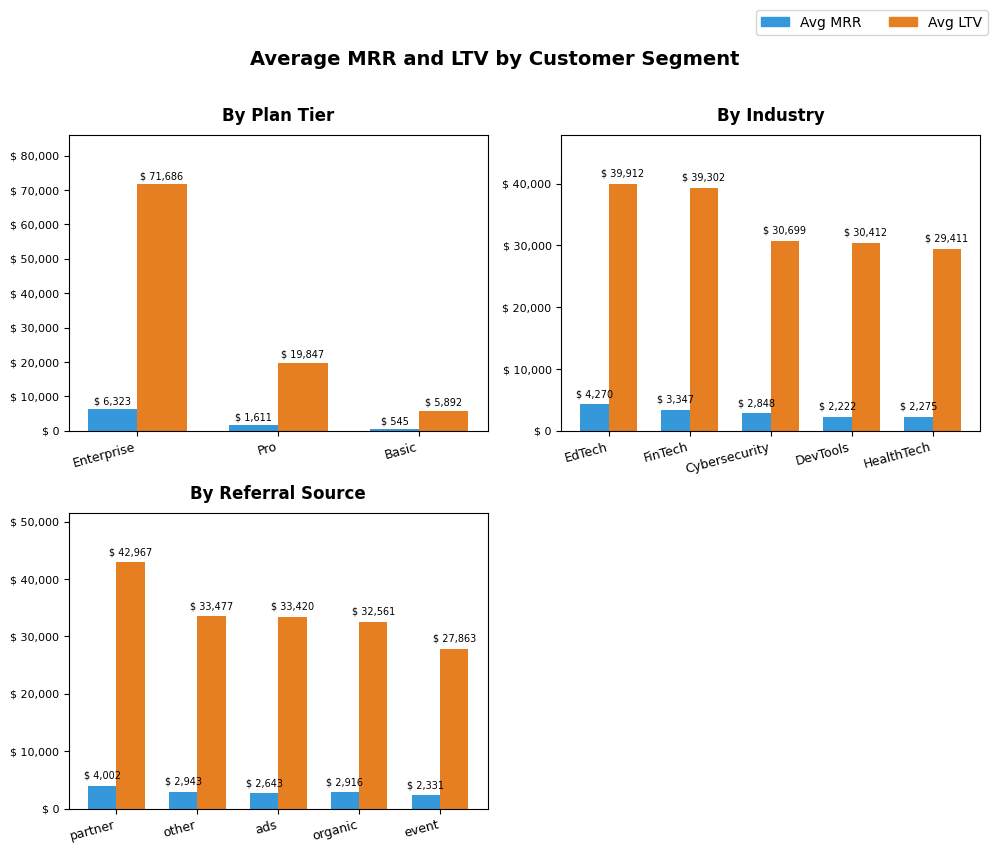

In [193]:
# Q1 - Average MRR and LTV by segment bar charts
# side by side bars showing both metrics per segment

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

datasets = [
    (plan_revenue, 'plan_tier', 'By Plan Tier'),
    (industry_revenue, 'industry', 'By Industry'),
    (referral_revenue, 'referral_source', 'By Referral Source')
]

bar_width = 0.35

for i, (data, col, title) in enumerate(datasets):
    ax = axes[i]
    sorted_data = data.sort_values('avg_ltv', ascending=False)
    
    x = range(len(sorted_data))
    
    # plot MRR bars
    mrr_bars = ax.bar(
        [pos - bar_width/2 for pos in x],
        sorted_data['avg_mrr'],
        width=bar_width,
        color='#3498db',
        label='Avg MRR'
    )
    
    # plot LTV bars
    ltv_bars = ax.bar(
        [pos + bar_width/2 for pos in x],
        sorted_data['avg_ltv'],
        width=bar_width,
        color='#e67e22',
        label='Avg LTV'
    )
    
    # add value labels on MRR bars
    for bar in mrr_bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + global_max * 0.01,
            f'$ {height:,.0f}',
            ha='center',
            va='bottom',
            fontsize=7
        )
    
    # add value labels on LTV bars
    for bar in ltv_bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + global_max * 0.01,
            f'$ {height:,.0f}',
            ha='center',
            va='bottom',
            fontsize=7
        )
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
   # ax.set_ylabel('Value (USD)')
    ax.set_xticks(list(x))
    ax.set_xticklabels(sorted_data[col], rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, sorted_data['avg_ltv'].max() * 1.2)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'$ {x:,.0f}')
    )
    ax.tick_params(axis='y', labelsize=8)
   # ax.legend(fontsize=8)

# single shared legend
handles = [
    plt.Rectangle((0,0), 1, 1, color='#3498db'),
    plt.Rectangle((0,0), 1, 1, color='#e67e22')
]
fig.legend(
    handles,
    ['Avg MRR', 'Avg LTV'],
    loc='lower right',
    bbox_to_anchor=(1, 1.02),
    ncol=2,
    fontsize=10,
    frameon=True
)

# hide the empty 4th subplot
axes[3].set_visible(False)

plt.suptitle('Average MRR and LTV by Customer Segment',
             fontsize=14, fontweight='bold', y=1.01) 

plt.tight_layout()
plt.show()

#### Q1 - Key Findings

**To the CFO and Head of Sales:**

RavenStack's revenue base is structurally concentrated and uneven across all three segmentation dimensions - plan tier, industry, and acquisition channel.

**Revenue by plan tier:**   
Enterprise generates 76.7% of total MRR despite representing 35.8% of accounts. This creates both opportunity and risk.  
The opportunity: average Enterprise LTV of USD 71,686 means every Enterprise customer retained is worth 3.6x a Pro customer and 12x a Basic customer.  The risk: losing even a small number of Enterprise accounts has an outsized revenue impact.  
Customer Success resources should be disproportionately allocated to Enterprise retention.

**Revenue by industry:**   
EdTech produces the highest average LTV (USD 39,912) with the fewest accounts (63) - meaning EdTech customers are both rarer and more valuable than other segments. This suggests EdTech is an underserved acquisition opportunity: the segment already demonstrates high willingness to pay and long tenure, but RavenStack has acquired fewer EdTech customers than any other industry.  
HealthTech sits at the opposite end - most accounts, lowest LTV - suggesting either shorter tenures or lower plan tiers in that segment.  

**Revenue by referral source:**   
Partner channel delivers the highest average LTV (USD 42,967) from only 69 accounts - the most capital-efficient acquisition channel in the business.  Every partner-referred customer generates USD 15,104 more lifetime value than an event-referred customer on average. This suggests partner relationships are worth prioritizing for acquisition, though a full channel efficiency comparison would require Customer Acquisition Cost (CAC) data per channel, which is outside the scope of this dataset.  
Event channel underperforms on LTV despite being the second most active channel by account count - suggesting event-acquired customers either churn faster or stay on lower plans.

#### Expansion Analysis - Data Validation

In [184]:
# check upgrade flag distribution in q1_df
print(f"Accounts with upgrade_flag True: {q1_df['upgrade_flag'].sum()}")
print(f"Total accounts in q1_df: {len(q1_df)}")
print(f"Overall upgrade rate: {q1_df['upgrade_flag'].mean() * 100:.1f}%")

Accounts with upgrade_flag True: 35
Total accounts in q1_df: 386
Overall upgrade rate: 9.1%


In [152]:
# get full subscription history per account sorted by date
subscription_history = subscriptions[
    subscriptions['is_trial'] == False
].sort_values(['account_id', 'start_date'])

print(subscription_history[['account_id', 'start_date', 'plan_tier', 'upgrade_flag', 'downgrade_flag']].head(15))

     account_id start_date   plan_tier  upgrade_flag  downgrade_flag
1940   A-00bed1 2023-11-16       Basic          True           False
4411   A-00bed1 2024-04-06         Pro         False           False
3774   A-00bed1 2024-05-06  Enterprise          True           False
2855   A-00bed1 2024-05-14  Enterprise         False           False
109    A-00bed1 2024-07-16  Enterprise         False           False
3193   A-00bed1 2024-07-20         Pro         False           False
3857   A-00bed1 2024-08-06         Pro         False           False
678    A-00bed1 2024-08-18         Pro          True           False
3126   A-00bed1 2024-09-01  Enterprise         False           False
4019   A-00cac8 2023-09-16         Pro         False           False
3557   A-00cac8 2023-12-26       Basic         False           False
1534   A-00cac8 2024-03-03       Basic         False           False
1980   A-00cac8 2024-08-04       Basic         False           False
3711   A-00cac8 2024-08-09  Enterp

**Subscription history exploration:**   
The full subscription history reveals that accounts have multiple subscription records reflecting plan changes 
over time. Account `A-00bed1` for example has 9 records spanning Basic, Pro, and Enterprise across 2023–2024.  

However investigation of `upgrade_flag` and `downgrade_flag` reveals these columns are unreliable in this dataset - flags are inconsistently assigned and do not consistently reflect actual plan tier changes.  
For example `A-00bed1` shows `upgrade_flag = True` on its initial Basic subscription, and `A-00cac8` shows clear plan downgrades (Pro → Basic) with no corresponding `downgrade_flag = True`.

**Decision:**  
Upgrade and downgrade flags will not be used for expansion analysis. Instead, expansion behavior will be derived directly from subscription history by comparing consecutive plan tier changes per account - a more reliable approach for this dataset.

In [155]:
# Q1 - Deriving expansion behavior from subscription history
# Since upgrade_flag is unreliable we compare consecutive plan tiers
# per account to identify real upgrades and downgrades

# define plan tier order - higher number = higher tier
plan_order = {'Basic': 1, 'Pro': 2, 'Enterprise': 3}

# get non-trial subscription history sorted by account and date
history = subscriptions[
    subscriptions['is_trial'] == False
].sort_values(['account_id', 'start_date']).copy()

# map plan tier to numeric order for comparison
history['plan_rank'] = history['plan_tier'].map(plan_order)

# for each account, get the previous plan rank using shift()
history['prev_plan_rank'] = history.groupby('account_id')['plan_rank'].shift(1)

# classify each subscription record as upgrade, downgrade, or no change
# first record per account will have NaN for prev_plan_rank - that's the starting plan
history['movement'] = 'no_change'
history.loc[history['plan_rank'] > history['prev_plan_rank'], 'movement'] = 'upgrade'
history.loc[history['plan_rank'] < history['prev_plan_rank'], 'movement'] = 'downgrade'

print(history[['account_id', 'start_date', 'plan_tier', 'plan_rank', 
               'prev_plan_rank', 'movement']].head(15))

     account_id start_date   plan_tier  plan_rank  prev_plan_rank   movement
1940   A-00bed1 2023-11-16       Basic          1             NaN  no_change
4411   A-00bed1 2024-04-06         Pro          2             1.0    upgrade
3774   A-00bed1 2024-05-06  Enterprise          3             2.0    upgrade
2855   A-00bed1 2024-05-14  Enterprise          3             3.0  no_change
109    A-00bed1 2024-07-16  Enterprise          3             3.0  no_change
3193   A-00bed1 2024-07-20         Pro          2             3.0  downgrade
3857   A-00bed1 2024-08-06         Pro          2             2.0  no_change
678    A-00bed1 2024-08-18         Pro          2             2.0  no_change
3126   A-00bed1 2024-09-01  Enterprise          3             2.0    upgrade
4019   A-00cac8 2023-09-16         Pro          2             NaN  no_change
3557   A-00cac8 2023-12-26       Basic          1             2.0  downgrade
1534   A-00cac8 2024-03-03       Basic          1             1.0  no_change

Expansion logic derived from consecutive plan tier comparisons using a numeric plan ranking (Basic=1, Pro=2, Enterprise=3).  
Each subscription record is classified as upgrade, downgrade, or no_change by comparing its plan rank to the previous record for the same account.  The first subscription record per account has no previous record (NaN) and is classified as no_change - the starting plan.

In [156]:
# summarize expansion behavior per account
# for each account: did they ever upgrade? ever downgrade?
# and what was their starting vs ending plan tier?

account_expansion = history.groupby('account_id').agg(
    upgrades=('movement', lambda x: (x == 'upgrade').sum()),
    downgrades=('movement', lambda x: (x == 'downgrade').sum()),
    starting_plan=('plan_tier', 'first'),
    ending_plan=('plan_tier', 'last')
).reset_index()

# flag accounts that ever upgraded or downgraded
account_expansion['ever_upgraded'] = account_expansion['upgrades'] > 0
account_expansion['ever_downgraded'] = account_expansion['downgrades'] > 0

print(f"Accounts that ever upgraded:   {account_expansion['ever_upgraded'].sum()}")
print(f"Accounts that ever downgraded: {account_expansion['ever_downgraded'].sum()}")
print(f"\nSample:")
print(account_expansion.head())

Accounts that ever upgraded:   466
Accounts that ever downgraded: 478

Sample:
  account_id  upgrades  downgrades starting_plan ending_plan  ever_upgraded  \
0   A-00bed1         3           1         Basic  Enterprise           True   
1   A-00cac8         2           3           Pro         Pro           True   
2   A-0158bb         1           0         Basic         Pro           True   
3   A-016043         4           4         Basic       Basic           True   
4   A-019782         2           2           Pro       Basic           True   

   ever_downgraded  
0             True  
1             True  
2            False  
3             True  
4             True  


In [157]:
# net expansion analysis
# compare starting plan to ending plan for each account
# this shows true long-term expansion regardless of intermediate bouncing

plan_order = {'Basic': 1, 'Pro': 2, 'Enterprise': 3}

account_expansion['starting_rank'] = account_expansion['starting_plan'].map(plan_order)
account_expansion['ending_rank'] = account_expansion['ending_plan'].map(plan_order)

account_expansion['net_movement'] = 'stable'
account_expansion.loc[
    account_expansion['ending_rank'] > account_expansion['starting_rank'], 
    'net_movement'] = 'expanded'
account_expansion.loc[
    account_expansion['ending_rank'] < account_expansion['starting_rank'], 
    'net_movement'] = 'contracted'

print(account_expansion['net_movement'].value_counts())
print(f"\nNet expansion rate: {(account_expansion['net_movement'] == 'expanded').mean() * 100:.1f}%")
print(f"Net contraction rate: {(account_expansion['net_movement'] == 'contracted').mean() * 100:.1f}%")

net_movement
stable        168
expanded      166
contracted    166
Name: count, dtype: int64

Net expansion rate: 33.2%
Net contraction rate: 33.2%


**Expansion analysis finding:**   
Net expansion and contraction rates are almost perfectly equal - 33.2% expanded, 33.2% contracted, 33.6% stable. 
This artificial balance confirms that plan movements in this dataset were generated randomly rather than following realistic business behavior.  

**Decision:**   
Expansion behavior will not be used as an analytical metric in Q1.  
The `upgrade_flag` and `downgrade_flag` columns are unreliable, and net plan movement analysis produces meaningless results due to synthetic data randomness.  
Q1 will focus on revenue segmentation - MRR and LTV by plan tier, industry, and referral source.